## Exportacion de modelo de ONNX - Clasificación de Aprobación de Préstamo

En este notebook, se describe el flujo de trabajo ejecutado para el entrenamiento, evaluación y exportación de un modelo de Machine Learning diseñado para predecir la aprobación de préstamos.

El conjunto de datos utilizado proviene de Kaggle y consta de 45,000 registros y 14 columnas (13 características y 1 variable objetivo).

El dataset sintético de 10,000 registros simula condiciones reales de la industria. Cada fila representa un punto de datos de una máquina. El objectivo es exportar un modelo de ONNX para ejecutar inferencia en C#.

Enlace de conjunto de datos: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

### 1. Importación de Librerías y Carga de Datos

En la primera sección del código, se importan las herramientas de manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), preprocesamiento y modelado espacial (`scikit-learn`), así como las librerías necesarias para la exportación del modelo a ONNX (`skl2onnx`).

In [124]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType, StringTensorType, Int64TensorType

Los datos se cargan desde el archivo local `../data/loan_data.csv` en un DataFrame de Pandas.

In [125]:
data = pd.read_csv('../data/loan_data.csv')
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


### 2. Análisis exploratorio de datos (EDA)

Mediante `data.info()` y `data.describe().T`, se observa que el conjunto contiene datos numéricos (float64, int64) y categóricos (str).

| Column                         | Descripción                                                      | Tipo    |
|--------------------------------|------------------------------------------------------------------|---------|
| person_age                     | Edad de la persona                                               | float64 |
| person_gender                  | Género de la persona                                             | str     |
| person_education               | Nivel de educación más alto                                      | str     | 
| person_income                  | Salario anual                                                    | float64 | 
| person_emp_exp                 | Años de experiencia laboral                                      | int64   |
| person_home_ownership          | Estado de propiedad del hogar (por ejemplo, rent, own, mortgage) | str     | 
| loan_amnt                      | Importe del préstamo solicitado                                  | float64 |
| loan_intent                    | Propósito del préstamo                                           | str     |
| loan_int_rate                  | Tarifa de interés del préstamo                                   | float64 |
| loan_percent_income            | Importe del préstamo como porcentaje del salario anual           | float64 |
| cb_person_cred_hist_length     | Duración del historial crediticio en años                        | float64 |
| credit_score                   | Puntaje de crédito de la persona                                 | int64   | 
| previous_loan_defaults_on_file | Indicador de impagos de préstamos anteriores                     | str     | 
| loan_status                    | Estado de aprobación del préstamo: 1 = aprobado; 0 = rechazado   | int64   | 


In [126]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [127]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


Se verifica la existencia de valores faltantes calculando el porcentaje con `.isnull().mean()`, mostrando que el dataset no presenta valores nulos iniciales en ninguna de sus columnas

<Axes: >

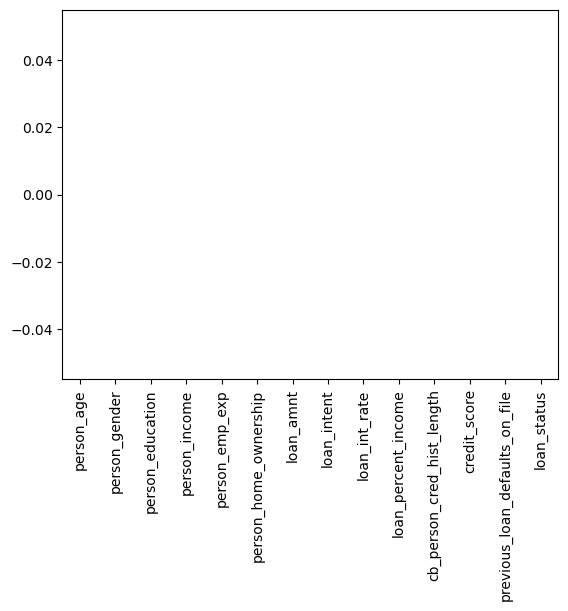

In [128]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

In [129]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

person_age                        0.0
person_gender                     0.0
person_education                  0.0
person_income                     0.0
person_emp_exp                    0.0
person_home_ownership             0.0
loan_amnt                         0.0
loan_intent                       0.0
loan_int_rate                     0.0
loan_percent_income               0.0
cb_person_cred_hist_length        0.0
credit_score                      0.0
previous_loan_defaults_on_file    0.0
loan_status                       0.0
dtype: float64

Se grafica un countplot de la columna loan_status (0 = Rechazado, 1 = Aprobado), revelando un desbalance de clases (hay más préstamos rechazados que aprobados).

Text(0.5, 1.0, 'Distribución de la Aprobación del Préstamo (0 = Rechazado, 1 = Aprobado)')

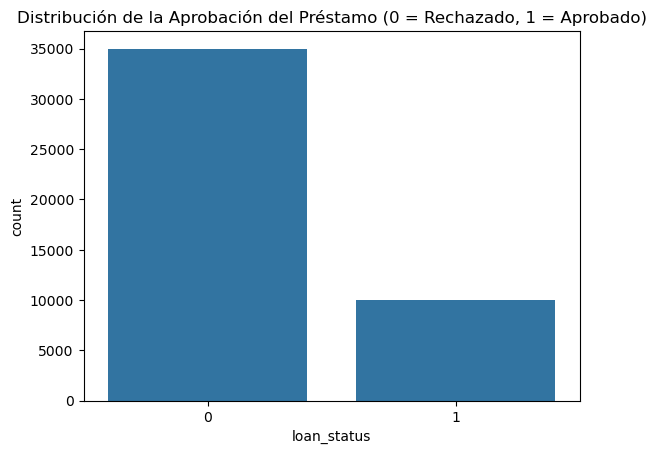

In [130]:
sns.countplot(data=data, x="loan_status")
plt.title("Distribución de la Aprobación del Préstamo (0 = Rechazado, 1 = Aprobado)")

Se generan histogramas para variables numéricas (como person_age, loan_amnt, person_income) y gráficos de barras para las variables categóricas (como person_gender, person_education).

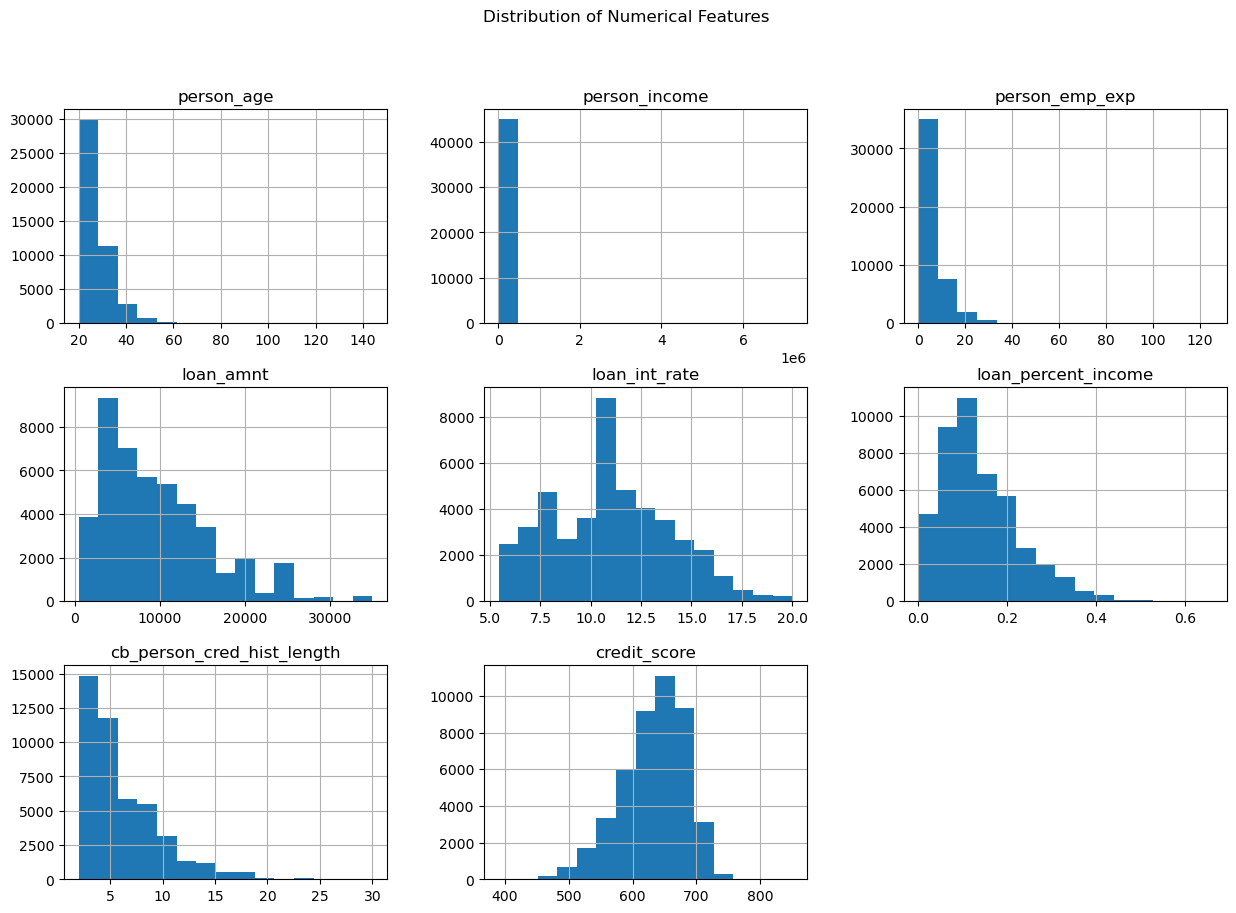

In [131]:
numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

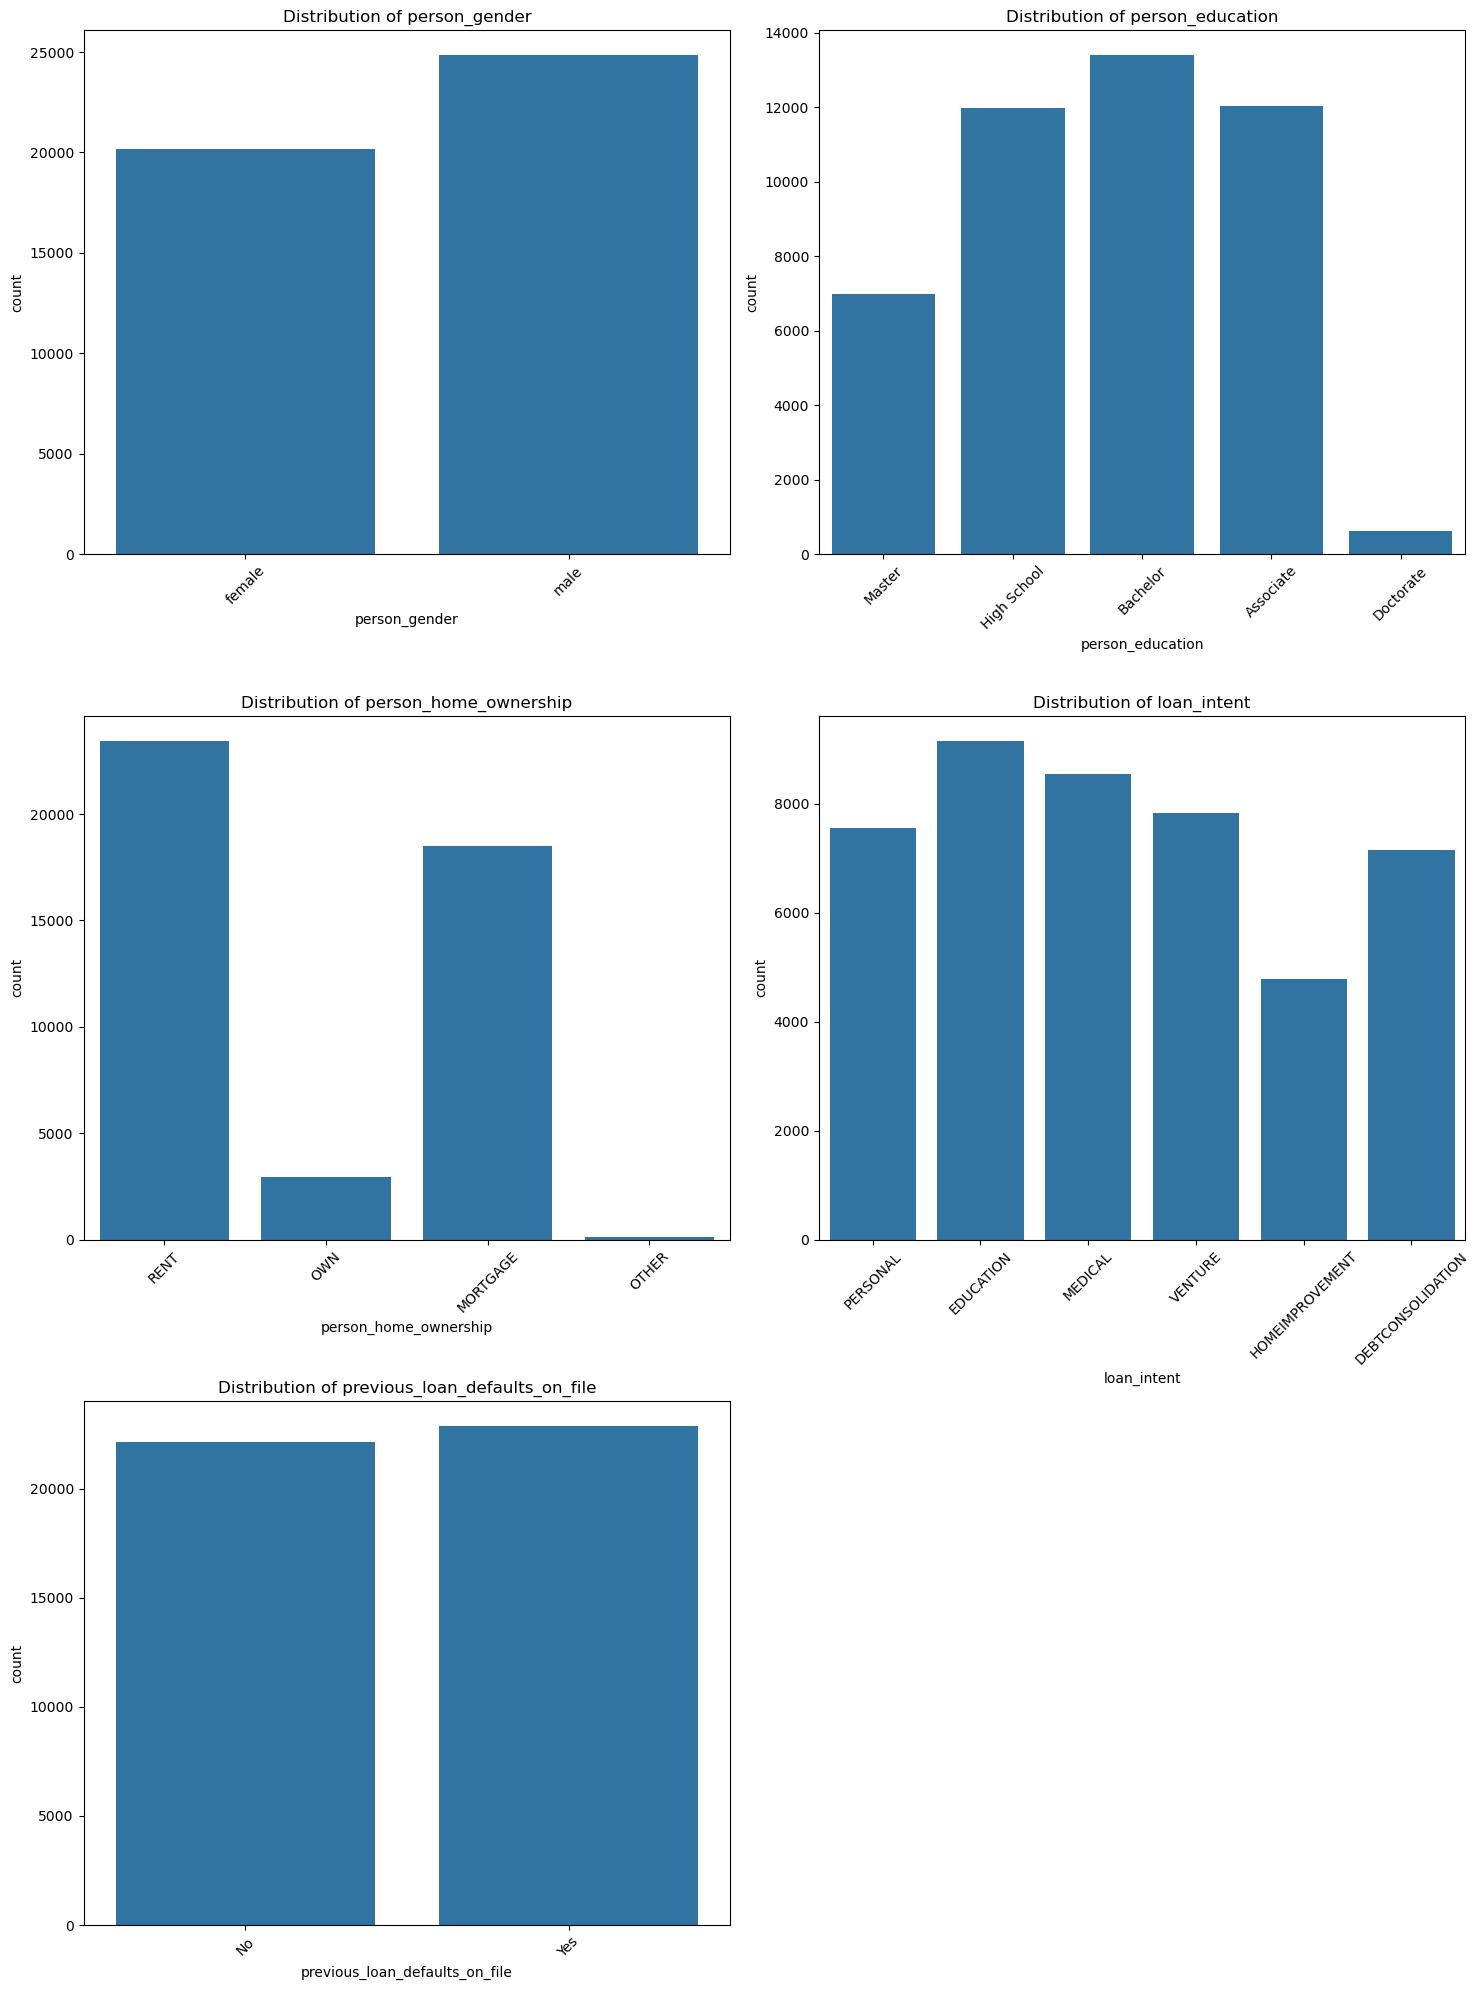

In [132]:
categorical_features = ["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=data, x=feature, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots sobrantes
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


Se explora la relación entre cada característica y la variable objetivo `loan_status` utilizando diagramas de caja (boxplots) para las variables numéricas y gráficos de conteo apilados por color (hue) para las categóricas.

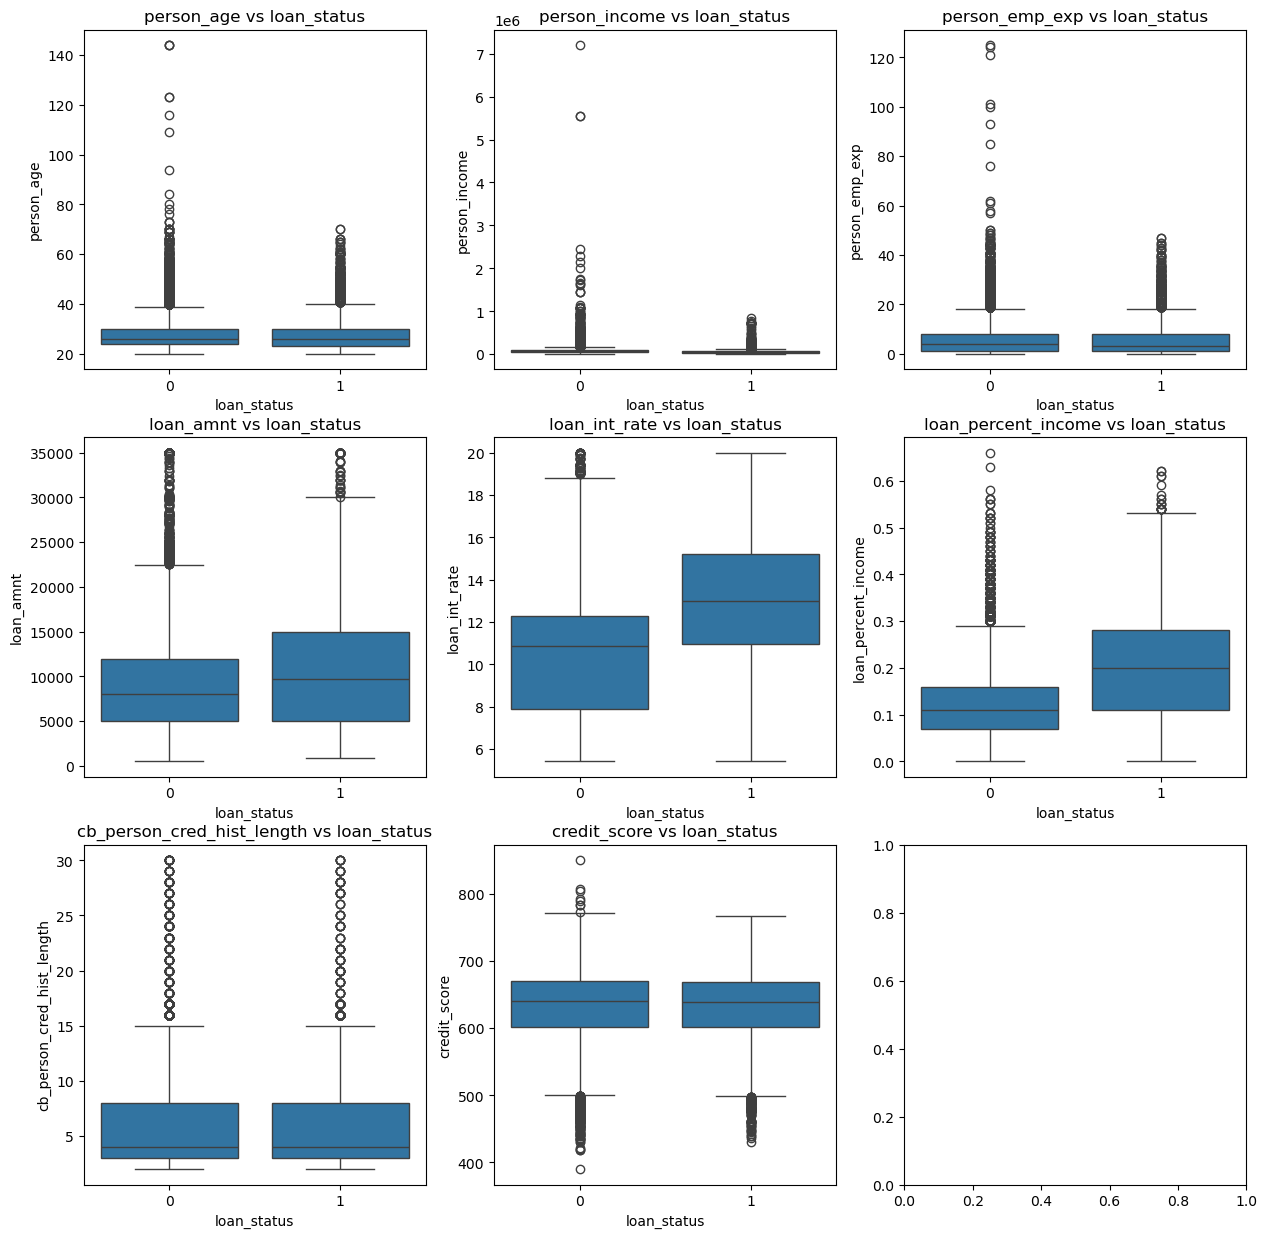

In [133]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=data, x="loan_status", y=feature, ax=ax)
    ax.set_title(f"{feature} vs loan_status")

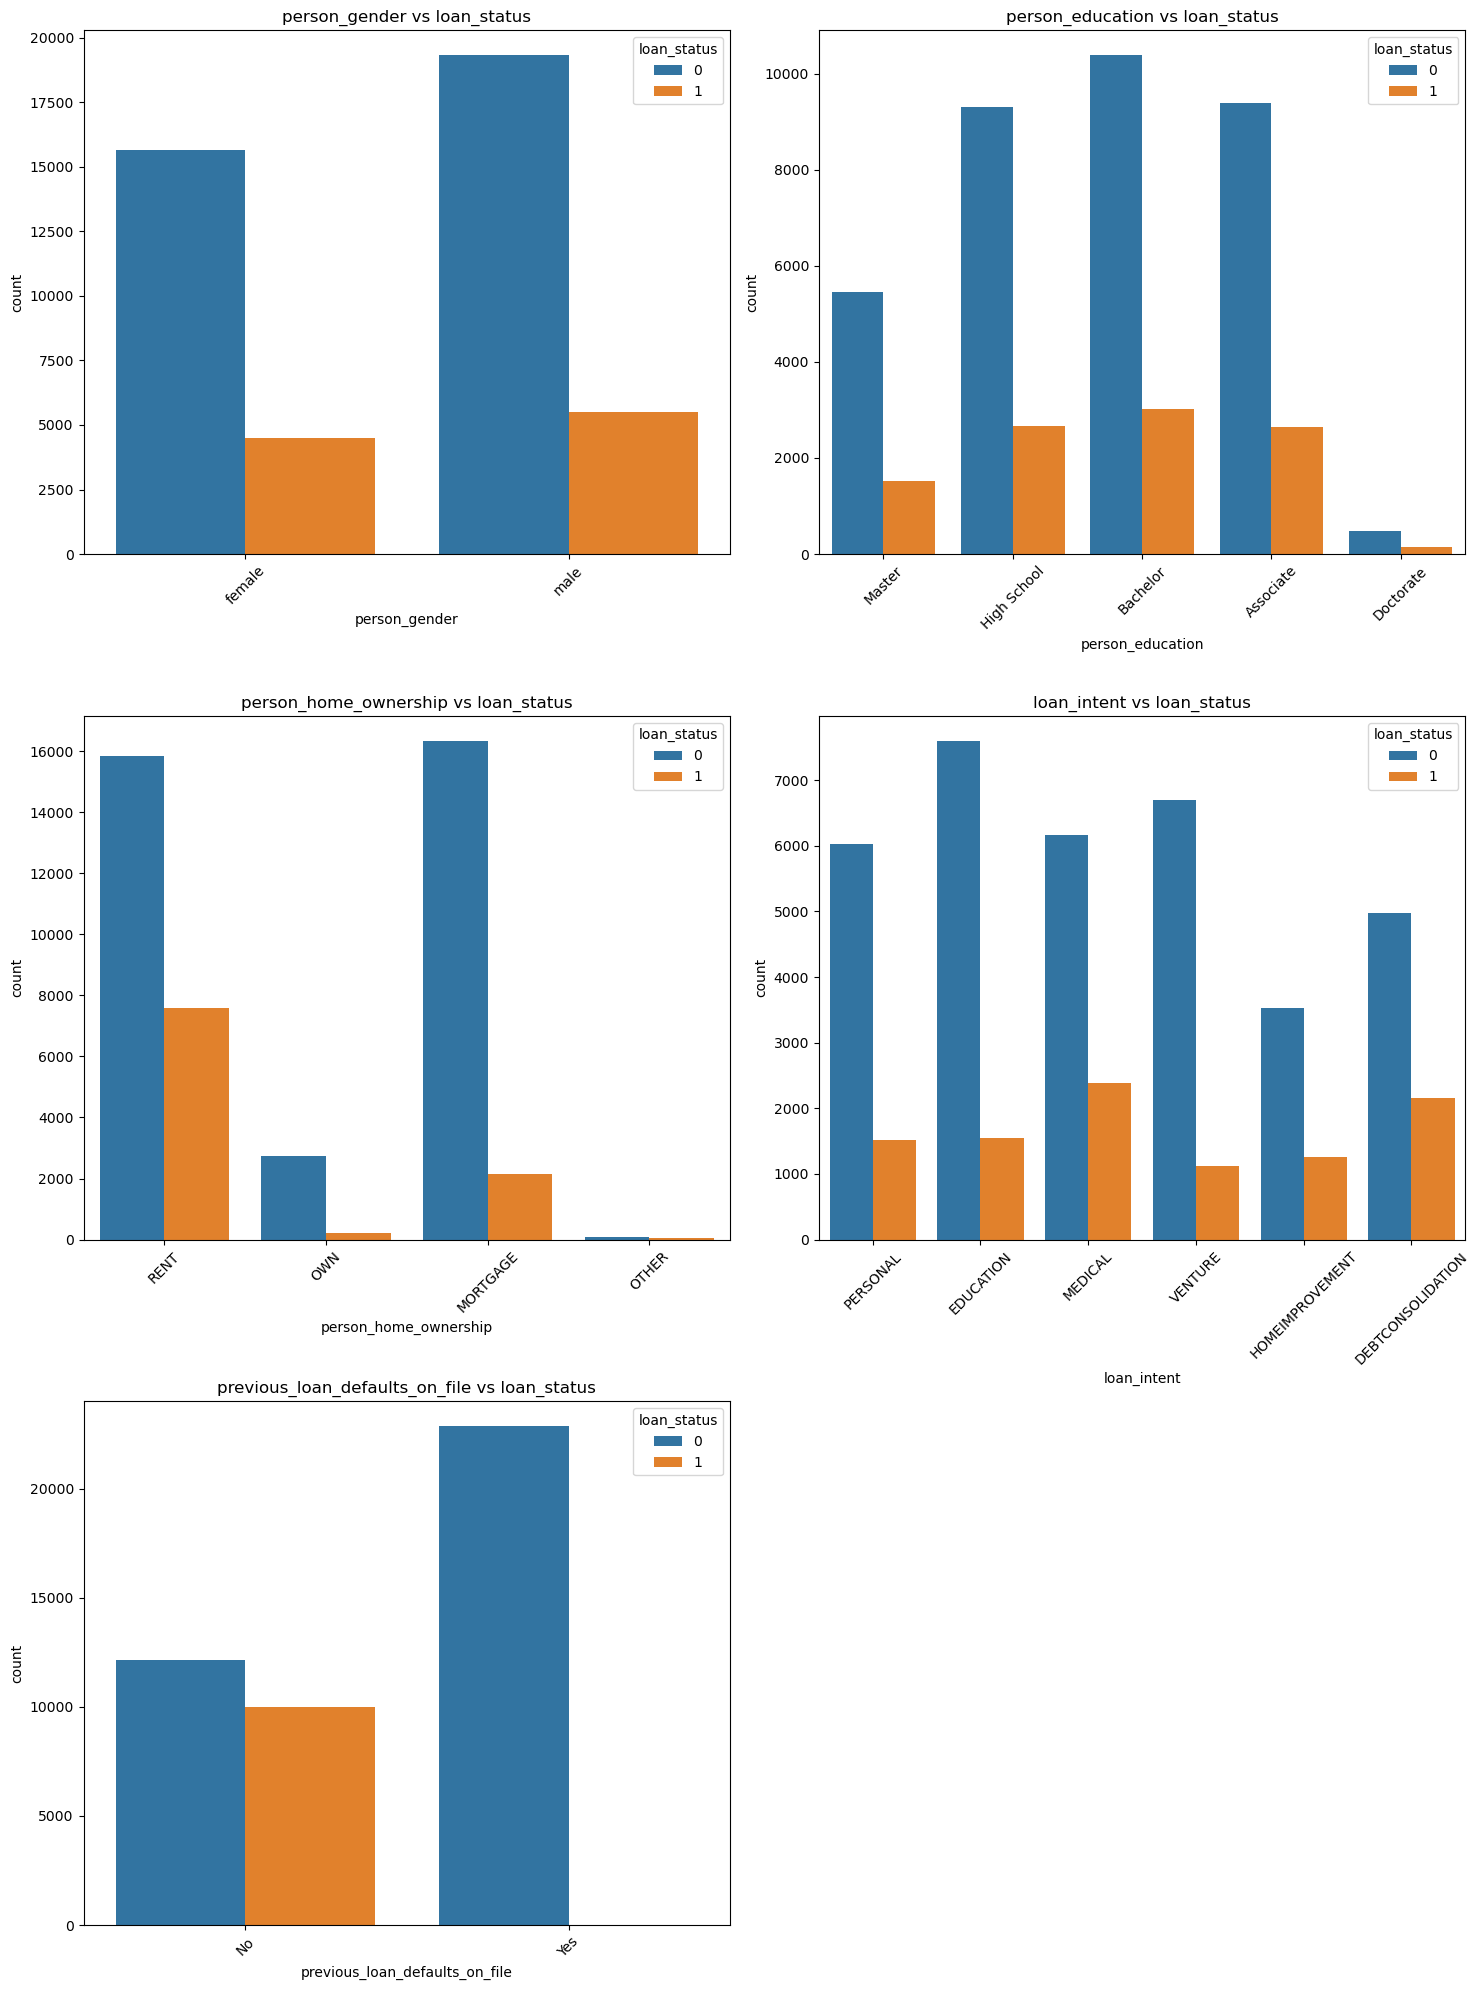

In [134]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=data, x=feature, hue="loan_status", ax=axes[i])
    axes[i].set_title(f"{feature} vs loan_status")
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots sobrantes
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

### 3. Preprocesamiento de Datos

Para preparar los datos para el algoritmo, se separan las variables predictoras (`X`) de la variable objetivo (`y`). Posteriormente, las variables se dividen en numéricas, categóricas nominales y categóricas ordinales.

Para evitar conflictos al exportar el modelo a ONNX, se fuerza la conversión de todas las columnas categóricas a tipo texto (**string**). Luego, se construyen transformadores (**Pipelines**) independientes:
 - **Variables Numéricas**: Se imputan posibles valores nulos usando la mediana (`SimpleImputer`) y se escalan mediante `StandardScaler`.
 - **Variables Categóricas Nominales**: Se imputan con el valor más frecuente y se codifican empleando `OneHotEncoder`.
 - **Variables Categóricas Ordinales** (Ej. Nivel de Educación): Se imputan con el valor más frecuente y se codifican manteniendo su jerarquía lógica a través de `OrdinalEncoder`.

Estos pasos se agrupan en un único `ColumnTransformer` que automatiza el proceso.


In [135]:
X = data.drop(columns=["loan_status"])
y = data['loan_status']

numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
cat_nominal_features = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
cat_ordinal_features = ['person_education']

# Definir el orden natural de la educación (de menor a mayor grado)
education_levels = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# Convertir todas las columnas categóricas a tipo string. 
# Esto transforma los np.nan (float) en el texto 'nan' automáticamente.
X[cat_nominal_features] = X[cat_nominal_features].astype(str)
X[cat_ordinal_features] = X[cat_ordinal_features].astype(str)

# Preprocesamiento para datos numéricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Rellena nulos numéricos con la mediana
    ('scaler', StandardScaler())                   # Escala los datos
])

# Preprocesamiento para datos categóricos nominales
categorical_nominal_transformer = Pipeline(steps=[
    # Le decimos al imputer que busque el texto 'nan'
    ('imputer', SimpleImputer(missing_values='nan', strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesamiento para datos categóricos ordinales
categorical_ordinal_transformer = Pipeline(steps=[
    # Le decimos al imputer que busque el texto 'nan'
    ('imputer', SimpleImputer(missing_values='nan', strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=education_levels, handle_unknown='use_encoded_value', unknown_value=-1))
])

# Unir ambos preprocesamientos en un ColumnTransformer
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat_nom', categorical_nominal_transformer, cat_nominal_features),
        ('cat_ord', categorical_ordinal_transformer, cat_ordinal_features)
    ])


In [136]:
X

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No


### 4. Entrenamiento del Modelo

Se divide el conjunto en datos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split` con estratificación (`stratify=y`) para mantener la proporción de las clases.

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
6048,24.0,male,Master,58914.0,2,OWN,4400.0,VENTURE,5.99,0.07,4.0,656,Yes
3346,23.0,female,High School,45873.0,2,RENT,11000.0,VENTURE,11.01,0.24,2.0,634,Yes
17998,29.0,female,Master,240947.0,7,MORTGAGE,10000.0,VENTURE,12.69,0.04,9.0,638,Yes
24988,30.0,female,Bachelor,96316.0,10,MORTGAGE,6000.0,MEDICAL,13.49,0.06,8.0,682,No
23231,29.0,male,Bachelor,73033.0,7,MORTGAGE,8000.0,PERSONAL,10.51,0.11,8.0,644,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3245,23.0,male,Bachelor,89921.0,3,RENT,3500.0,EDUCATION,12.87,0.04,3.0,634,Yes
17803,25.0,female,Associate,35911.0,2,RENT,3000.0,EDUCATION,6.62,0.08,4.0,573,No
28842,30.0,male,Bachelor,72786.0,9,OWN,20000.0,EDUCATION,6.17,0.27,9.0,477,Yes
21553,30.0,male,Associate,39629.0,8,RENT,6000.0,MEDICAL,12.99,0.15,9.0,689,No


In [138]:
x_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
x_train_processed

array([[-0.62250234, -0.25660041, -0.56159695, ...,  0.        ,
         1.        ,  3.        ],
       [-0.78792093, -0.41126893, -0.56159695, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.20459064,  1.90234248,  0.26292019, ...,  0.        ,
         1.        ,  3.        ],
       ...,
       [ 0.37000923, -0.09207609,  0.59272705, ...,  0.        ,
         1.        ,  2.        ],
       [ 0.37000923, -0.48532385,  0.42782362, ...,  1.        ,
         0.        ,  1.        ],
       [-0.12624655, -0.37516656, -0.06688666, ...,  1.        ,
         0.        ,  3.        ]], shape=(36000, 23))

Se crea un pipeline global con `make_pipeline` que ensambla el preprocesador construido en el paso anterior y un estimador `RandomForestClassifier` con 100 árboles de decisión (`n_estimators=100`).

In [139]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Se entrena el pipeline completo invocando `.fit(X_train, y_train)`.

In [140]:
pipeline = make_pipeline(preprocessing_pipeline, model)
pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5. Evaluación del Modelo

Las predicciones sobre los datos de prueba (X_test) son evaluadas empleando diversas métricas de clasificación:

In [141]:
y_pred = pipeline.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9000,))

El modelo logró una exactitud general del 92.93%. Se genera un reporte de clasificación mostrando precisión de 92.81%, recuerdo de 92.93%, y puntuación de F1 de 92.73% promedio ponderados.

In [142]:
# Evaluación
print("--- Evaluación del Modelo ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print(f"Precisión (Precision): {precision_score(y_test, y_pred, average='weighted'):.4f}\n")
print(f"Recuerdo (Recall): {recall_score(y_test, y_pred, average='weighted'):.4f}\n")
print(f"Puntuación de F1 (F1 Score): {f1_score(y_test, y_pred, average='weighted'):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


--- Evaluación del Modelo ---
Exactitud (Accuracy): 0.9293

Precisión (Precision): 0.9281

Recuerdo (Recall): 0.9293

Puntuación de F1 (F1 Score): 0.9273

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



Para la Matriz de Confusión, se traza un mapa de calor (heatmap) ilustrando los verdaderos positivos/negativos contra los falsos positivos/negativos.

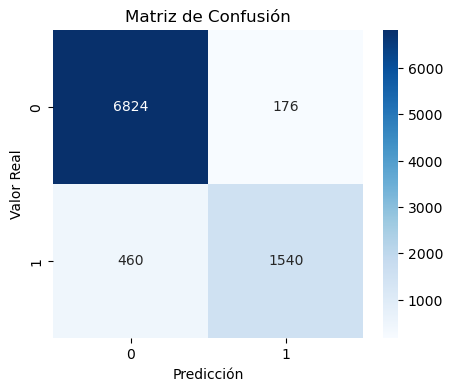

In [143]:
# Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Finalmente, los valores predichos y los reales se añaden como nuevas columnas al DataFrame de prueba para una inspección visual manual.

In [144]:
X_test["loan_status_predicted"] = y_pred
X_test["loan_status_actual"] = y_test.values
X_test

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status_predicted,loan_status_actual
10750,25.0,female,Bachelor,84973.0,2,MORTGAGE,14000.0,VENTURE,5.42,0.16,3.0,634,No,0,0
17512,24.0,male,Bachelor,87280.0,2,OWN,16000.0,EDUCATION,12.42,0.18,2.0,610,Yes,0,0
17070,22.0,female,Associate,70178.0,0,OWN,6500.0,VENTURE,7.49,0.09,3.0,668,Yes,0,0
35943,27.0,male,Bachelor,176144.0,1,MORTGAGE,2500.0,MEDICAL,8.49,0.01,6.0,591,Yes,0,0
15749,26.0,female,Bachelor,181548.0,3,MORTGAGE,10000.0,DEBTCONSOLIDATION,15.99,0.06,3.0,643,No,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10107,23.0,male,Associate,65677.0,1,RENT,9500.0,MEDICAL,14.65,0.14,2.0,605,Yes,0,0
34212,25.0,female,Master,68132.0,1,MORTGAGE,5000.0,PERSONAL,6.24,0.07,4.0,579,Yes,0,0
40679,24.0,female,Bachelor,52801.0,5,RENT,5000.0,EDUCATION,12.47,0.09,4.0,684,Yes,0,0
22371,33.0,male,Master,67209.0,7,MORTGAGE,3500.0,HOMEIMPROVEMENT,10.65,0.05,5.0,650,Yes,0,0


### 6. Exportación a ONNX

Para que el modelo sea consumido por aplicaciones desarrolladas en C#, el pipeline entrenado se serializa en el formato ONNX:
 - Se declaran dinámicamente los tipos de datos iniciales requeridos para la entrada (`StringTensorType` para los categóricos y `FloatTensorType` para los numéricos).
 - Se utiliza la función `to_onnx` especificando el modelo, los tipos iniciales y asegurando la compatibilidad con el ecosistema ONNX (`target_opset=12`).
 - El archivo resultante se guarda exitosamente en el directorio de salida bajo el nombre de `loan_model.onnx`.

In [145]:
# Unimos tus listas de características categóricas
categorical_cols = cat_nominal_features + cat_ordinal_features
numerical_int_cols = ['person_emp_exp', 'credit_score']  # Columnas numéricas que son enteros

# 1. Declarar los tipos iniciales dinámicamente
initial_types = []
for col in X.columns:
    if col in categorical_cols:
        initial_types.append((col, StringTensorType([None, 1])))
    elif col in numerical_int_cols:
        initial_types.append((col, Int64TensorType([None, 1])))
    else:
        initial_types.append((col, FloatTensorType([None, 1])))

# 2. Convertir a ONNX
onnx_model = to_onnx(
    pipeline, 
    initial_types=initial_types,
    target_opset=12 # Asegura compatibilidad
)

# 3. Guardar el archivo
dir = "../models/"
if not os.path.exists(dir):
    os.makedirs(dir)

with open("../models/loan_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("¡Modelo exportado exitosamente como 'loan_model.onnx'!")

¡Modelo exportado exitosamente como 'loan_model.onnx'!
